# 02 — AI Skill Compression

The centerpiece finding: **AI compresses the skill barrier for cognitive tasks.**

For each task, the Anthropic Economic Index estimates how many years of education
a human needs vs. how many years of equivalent training the AI needs. The difference —
*skill compression* — quantifies how much AI democratizes access to expertise.

Tasks with high skill compression (AI needs far less education than humans)
show systematically different automation patterns.

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.data import build_task_feature_matrix, _build_task_to_soc

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 150
C = {'auto': '#E63946', 'aug': '#457B9D', 'accent': '#F4A261', 'teal': '#2A9D8F'}

In [2]:
tasks = build_task_feature_matrix()
tasks_unique = tasks.drop_duplicates(subset='task_name').reset_index(drop=True)
print(f"Analyzing {len(tasks_unique):,} unique tasks")
print(f"\nSkill compression = human_education_years - ai_education_years")
print(f"  > 0: AI needs LESS education (AI democratizes)")
print(f"  < 0: AI needs MORE education (task resists AI compression)")
print(f"\nDistribution:")
print(tasks_unique['skill_compression'].describe())

Analyzing 3,259 unique tasks

Skill compression = human_education_years - ai_education_years
  > 0: AI needs LESS education (AI democratizes)
  < 0: AI needs MORE education (task resists AI compression)

Distribution:
count    3259.000000
mean       -0.155149
std         0.642822
min        -4.432432
25%        -0.490382
50%        -0.086153
75%         0.244648
max         2.600000
Name: skill_compression, dtype: float64


## The distribution of skill compression

Most tasks cluster near zero, but the tails are revealing:
- **Positive tail**: tasks where AI dramatically reduces the education barrier
- **Negative tail**: tasks where AI actually needs *more* training than humans

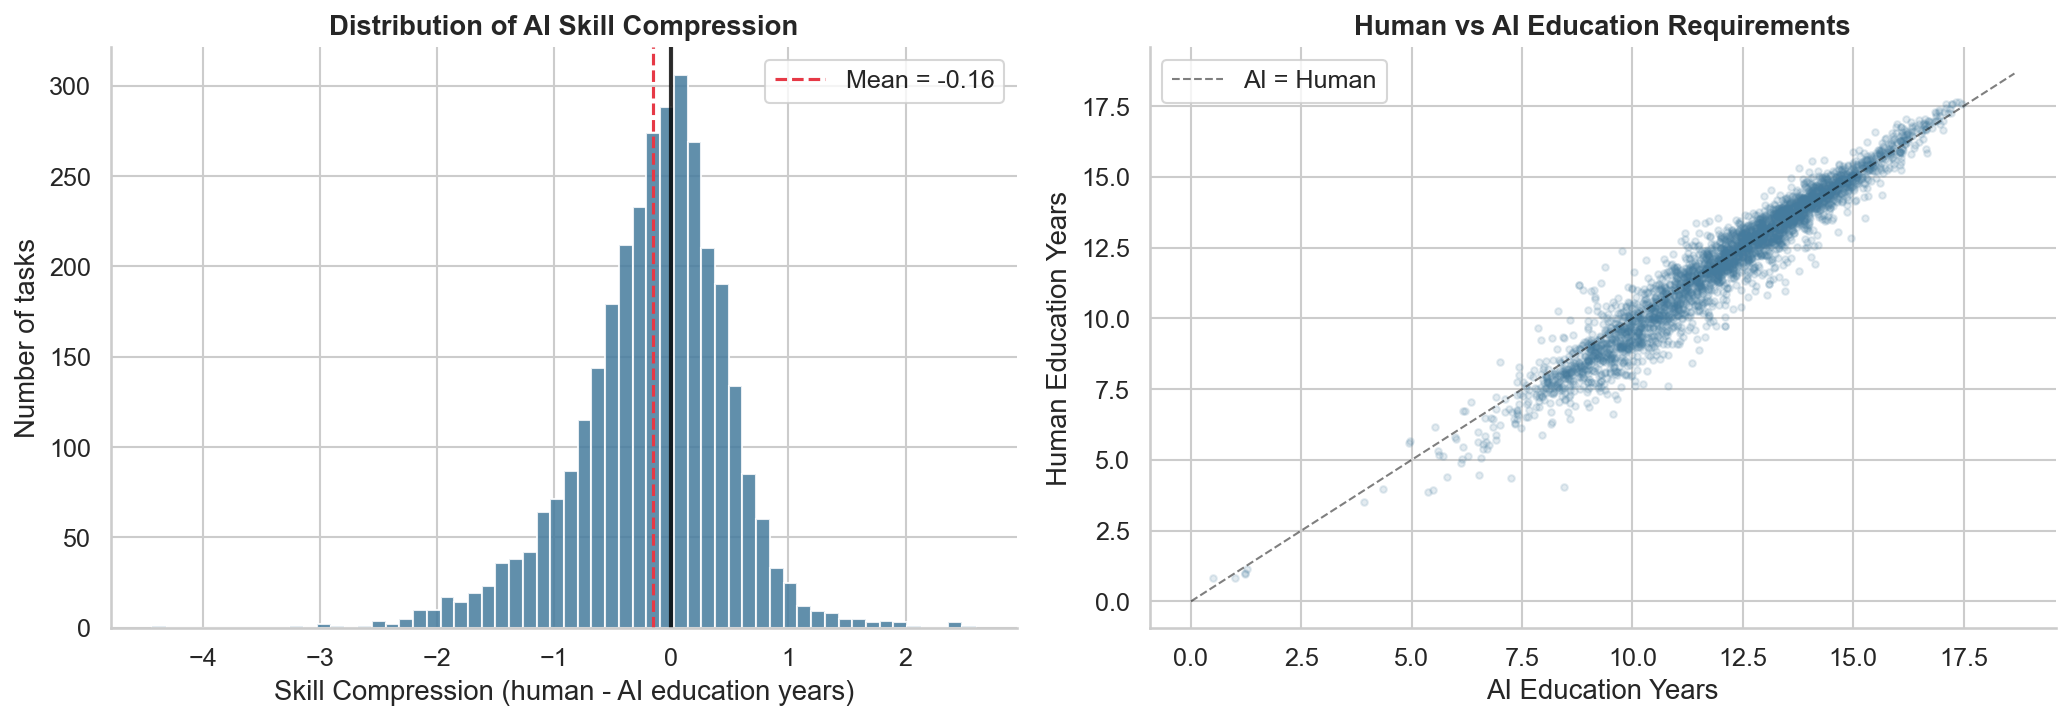

Tasks where AI needs less education: 1400 (43%)
Tasks where AI needs more education: 1801 (55%)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram
ax = axes[0]
data = tasks_unique['skill_compression'].dropna()
ax.hist(data, bins=60, color=C['aug'], alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=2, alpha=0.8)
ax.axvline(data.mean(), color=C['auto'], linestyle='--', linewidth=1.5,
           label=f'Mean = {data.mean():.2f}')
ax.set_xlabel('Skill Compression (human - AI education years)')
ax.set_ylabel('Number of tasks')
ax.set_title('Distribution of AI Skill Compression', fontweight='bold')
ax.legend()

# Right: human vs AI education years scatter
ax = axes[1]
ax.scatter(tasks_unique['ai_education_years'], tasks_unique['human_education_years'],
           alpha=0.15, s=10, color=C['aug'])
lim = [0, max(tasks_unique['human_education_years'].max(), tasks_unique['ai_education_years'].max()) + 1]
ax.plot(lim, lim, '--', color='black', linewidth=1, alpha=0.5, label='AI = Human')
ax.set_xlabel('AI Education Years')
ax.set_ylabel('Human Education Years')
ax.set_title('Human vs AI Education Requirements', fontweight='bold')
ax.legend()

sns.despine()
plt.tight_layout()
plt.savefig('../figures/04_skill_compression_distribution.png', bbox_inches='tight')
plt.show()

print(f"Tasks where AI needs less education: {(data > 0).sum()} ({(data > 0).mean():.0%})")
print(f"Tasks where AI needs more education: {(data < 0).sum()} ({(data < 0).mean():.0%})")

## Skill compression predicts automation patterns

The key finding: tasks with higher skill compression (AI needs less education)
show significantly higher automation shares. This is statistically robust
across 3,259 tasks.

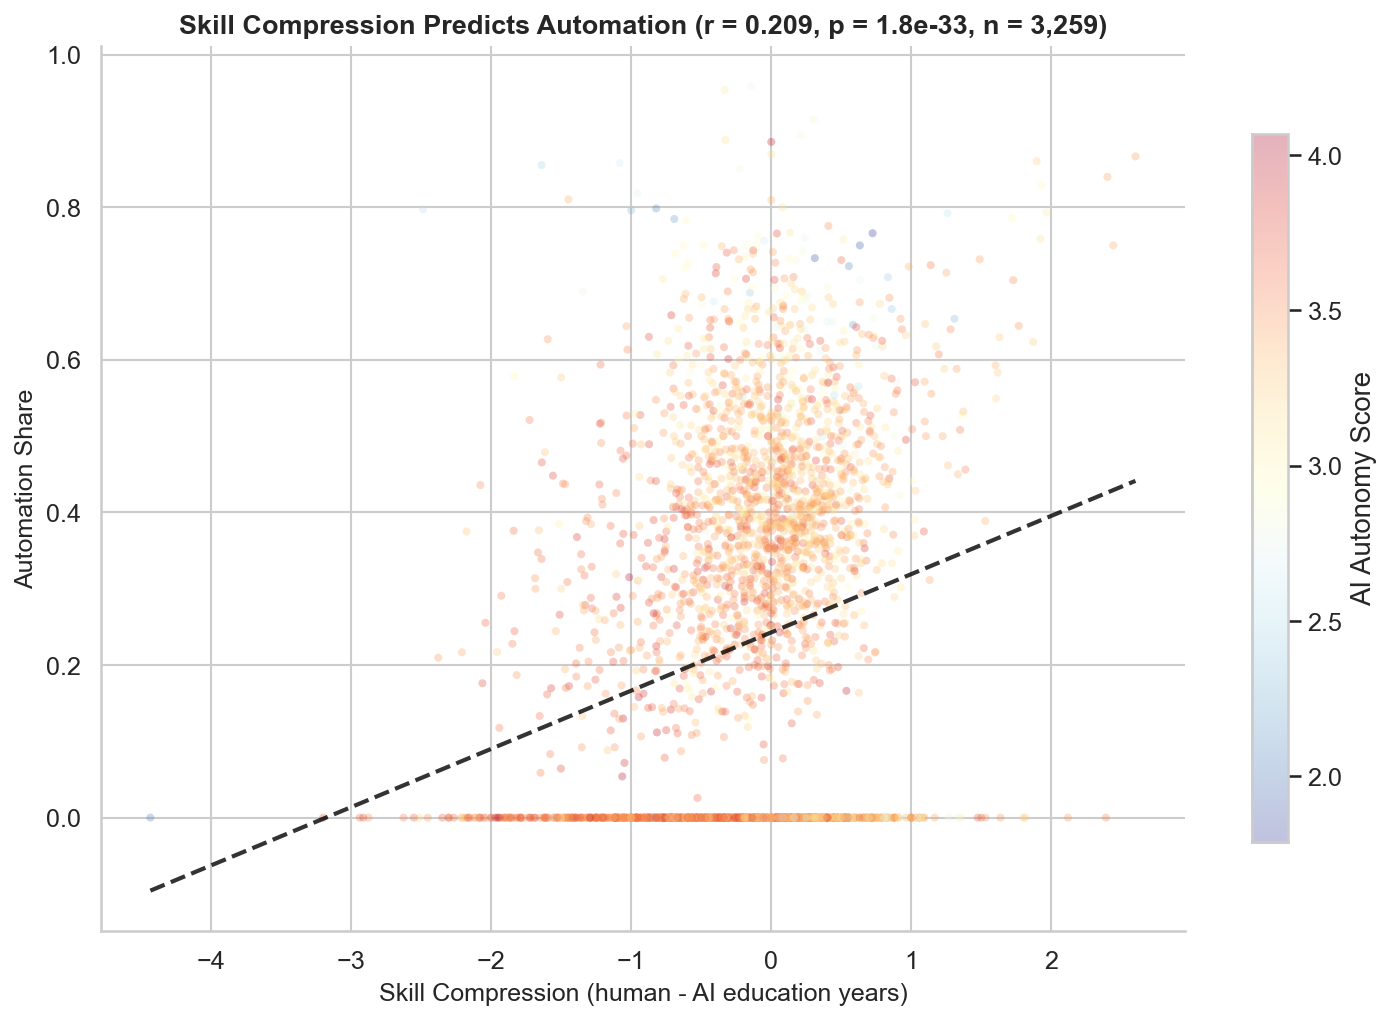

Pearson r = 0.209, p = 1.84e-33
For every 1-year increase in skill compression, automation share increases by 0.076


In [4]:
valid = tasks_unique.dropna(subset=['skill_compression', 'automation_share']).copy()
r, p = stats.pearsonr(valid['skill_compression'], valid['automation_share'])

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(valid['skill_compression'], valid['automation_share'],
                     c=valid['ai_autonomy_mean'], cmap='RdYlBu_r',
                     alpha=0.3, s=15, edgecolors='none')
plt.colorbar(scatter, ax=ax, label='AI Autonomy Score', shrink=0.8)

# Trend line
z = np.polyfit(valid['skill_compression'], valid['automation_share'], 1)
p_line = np.poly1d(z)
x_line = np.linspace(valid['skill_compression'].min(), valid['skill_compression'].max(), 100)
ax.plot(x_line, p_line(x_line), '--', color='black', linewidth=2, alpha=0.8)

ax.set_xlabel('Skill Compression (human - AI education years)', fontsize=12)
ax.set_ylabel('Automation Share', fontsize=12)
ax.set_title(f'Skill Compression Predicts Automation (r = {r:.3f}, p = {p:.1e}, n = {len(valid):,})',
             fontsize=13, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('../figures/05_skill_compression_vs_automation.png', bbox_inches='tight')
plt.show()

print(f"Pearson r = {r:.3f}, p = {p:.2e}")
print(f"For every 1-year increase in skill compression, automation share increases by {z[0]:.3f}")

## Skill compression by occupation group

Which fields see the most AI skill democratization?

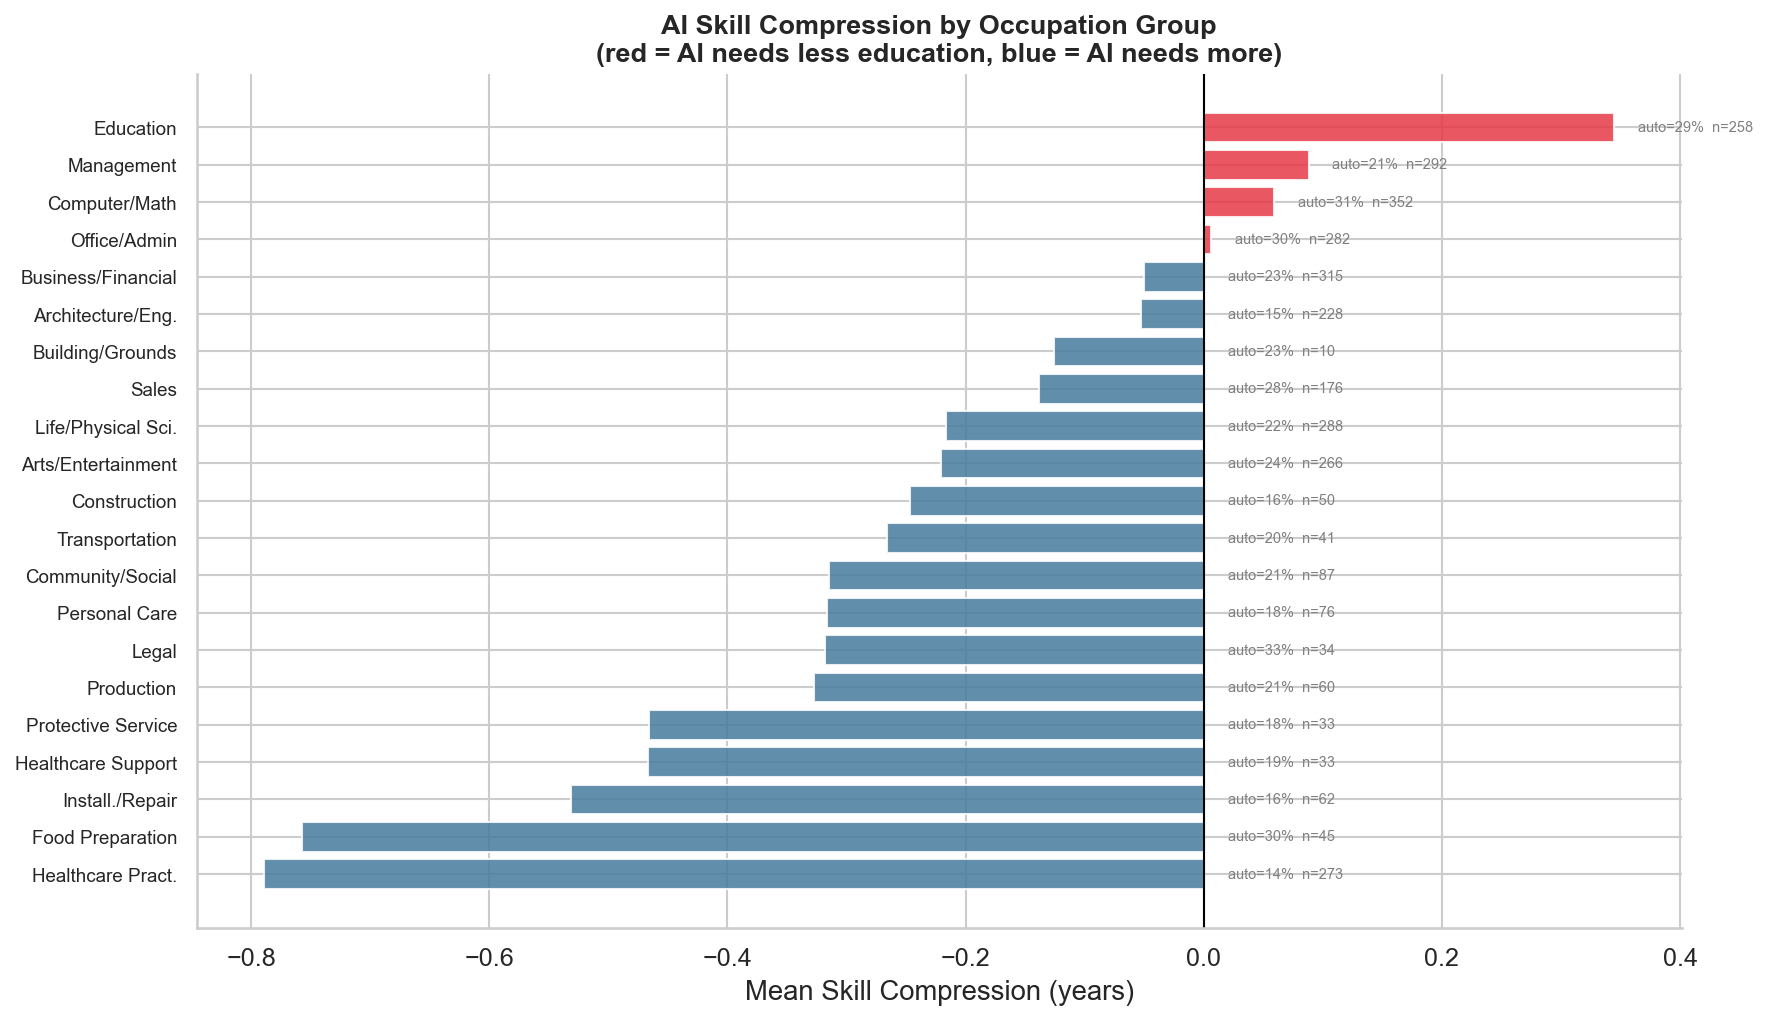

In [5]:
major_group_names = {
    '11': 'Management', '13': 'Business/Financial', '15': 'Computer/Math',
    '17': 'Architecture/Eng.', '19': 'Life/Physical Sci.',
    '21': 'Community/Social', '23': 'Legal', '25': 'Education',
    '27': 'Arts/Entertainment', '29': 'Healthcare Pract.',
    '31': 'Healthcare Support', '33': 'Protective Service',
    '35': 'Food Preparation', '37': 'Building/Grounds',
    '39': 'Personal Care', '41': 'Sales', '43': 'Office/Admin',
    '45': 'Farming/Fishing', '47': 'Construction', '49': 'Install./Repair',
    '51': 'Production', '53': 'Transportation',
}

tasks['group_name'] = tasks['soc_code'].astype(str).str[:2].map(major_group_names)
group_sc = (
    tasks.dropna(subset=['skill_compression', 'group_name'])
    .groupby('group_name')
    .agg(
        mean_sc=('skill_compression', 'mean'),
        mean_auto=('automation_share', 'mean'),
        n=('task_name', 'nunique'),
    )
    .query('n >= 10')
    .sort_values('mean_sc')
)

fig, ax = plt.subplots(figsize=(12, 7))
colors = [C['auto'] if v > 0 else C['aug'] for v in group_sc['mean_sc']]
ax.barh(range(len(group_sc)), group_sc['mean_sc'], color=colors, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)

for i, (name, row) in enumerate(group_sc.iterrows()):
    ax.text(max(row['mean_sc'], 0) + 0.02, i,
            f"auto={row['mean_auto']:.0%}  n={row['n']:.0f}",
            va='center', fontsize=7, color='gray')

ax.set_yticks(range(len(group_sc)))
ax.set_yticklabels(group_sc.index, fontsize=9)
ax.set_xlabel('Mean Skill Compression (years)')
ax.set_title('AI Skill Compression by Occupation Group\n(red = AI needs less education, blue = AI needs more)',
             fontsize=13, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('../figures/06_skill_compression_by_group.png', bbox_inches='tight')
plt.show()

## Most and least compressed tasks

What specific tasks does AI democratize most — and which resist compression?

In [6]:
print('TOP 10 — Tasks where AI compresses skill barrier most (AI needs far less education):')
print('=' * 90)
for _, row in tasks_unique.nlargest(10, 'skill_compression').iterrows():
    print(f"  [{row['skill_compression']:+.1f} years]  {row['task_name'][:80]}")
    print(f"      Human: {row['human_education_years']:.1f}y, AI: {row['ai_education_years']:.1f}y, "
          f"Auto: {row['automation_share']:.0%}")

print()
print('BOTTOM 10 — Tasks where AI needs MORE education than humans:')
print('=' * 90)
for _, row in tasks_unique.nsmallest(10, 'skill_compression').iterrows():
    print(f"  [{row['skill_compression']:+.1f} years]  {row['task_name'][:80]}")
    print(f"      Human: {row['human_education_years']:.1f}y, AI: {row['ai_education_years']:.1f}y, "
          f"Auto: {row['automation_share']:.0%}")

TOP 10 — Tasks where AI compresses skill barrier most (AI needs far less education):
  [+2.6 years]  consult with clients to identify survey needs and specific requirements, such as
      Human: 12.4y, AI: 9.8y, Auto: 87%
  [+2.4 years]  define instructional, learning, or performance objectives.
      Human: 11.8y, AI: 9.4y, Auto: 75%
  [+2.4 years]  conduct needs assessments and strategic learning assessments to develop the basi
      Human: 11.2y, AI: 8.8y, Auto: 84%
  [+2.4 years]  interview key staff or tour facilities to identify efficiency-improvement, cost-
      Human: 11.2y, AI: 8.8y, Auto: 0%
  [+2.1 years]  determine training needs of students or workers.
      Human: 11.0y, AI: 8.9y, Auto: 0%
  [+2.0 years]  determine guidelines that specify which source material is acceptable for use.
      Human: 11.2y, AI: 9.3y, Auto: 79%
  [+1.9 years]  prepare detailed storyboards showing sequence and timing of story development fo
      Human: 13.4y, AI: 11.4y, Auto: 83%
  [+1.9 years

## Skill compression and AI autonomy

Skill compression also correlates with AI autonomy — tasks where AI compresses
the education barrier tend to have *lower* AI autonomy scores, suggesting AI
is used more as a tool for extending human capability than as an autonomous agent.

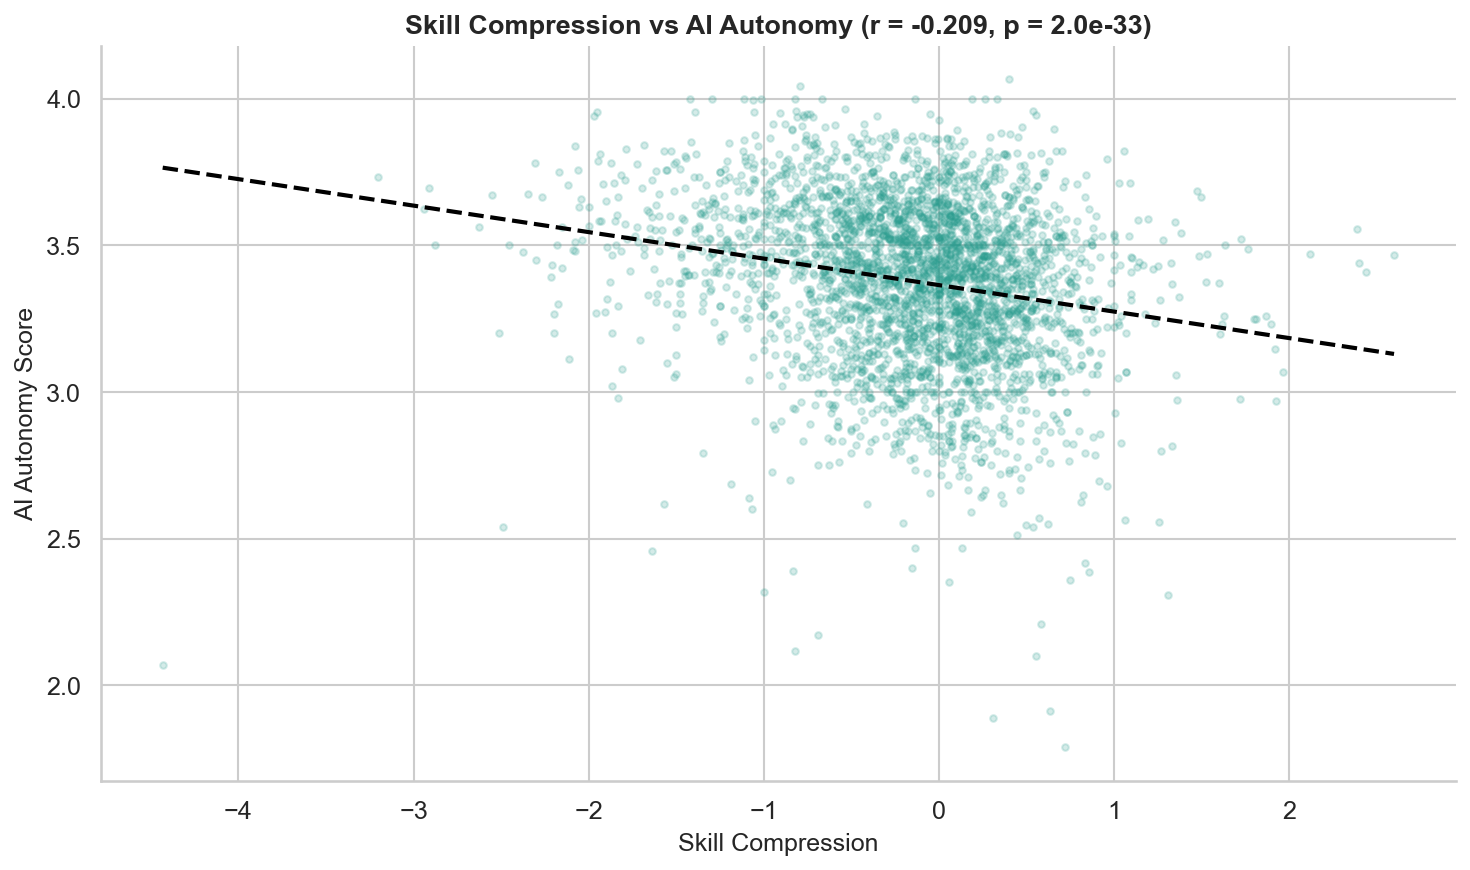

Negative correlation: tasks where AI compresses education tend to have
lower autonomy — AI augments rather than replaces.


In [7]:
r_auto, p_auto = stats.pearsonr(
    tasks_unique['skill_compression'].dropna(),
    tasks_unique.loc[tasks_unique['skill_compression'].notna(), 'ai_autonomy_mean']
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(tasks_unique['skill_compression'], tasks_unique['ai_autonomy_mean'],
           alpha=0.2, s=10, color=C['teal'])

z = np.polyfit(tasks_unique['skill_compression'].dropna(),
               tasks_unique.loc[tasks_unique['skill_compression'].notna(), 'ai_autonomy_mean'], 1)
ax.plot(x_line, np.poly1d(z)(x_line), '--', color='black', linewidth=2)

ax.set_xlabel('Skill Compression', fontsize=12)
ax.set_ylabel('AI Autonomy Score', fontsize=12)
ax.set_title(f'Skill Compression vs AI Autonomy (r = {r_auto:.3f}, p = {p_auto:.1e})',
             fontsize=13, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('../figures/07_skill_compression_vs_autonomy.png', bbox_inches='tight')
plt.show()

print(f"Negative correlation: tasks where AI compresses education tend to have")
print(f"lower autonomy — AI augments rather than replaces.")

---

**Key findings:**
1. **Skill compression is real and measurable** across 3,259 tasks
2. **Higher compression correlates with more automation** (r = 0.21, p < 1e-33)
3. **But compressed tasks have lower AI autonomy** — suggesting AI is a democratizing tool, not a replacement
4. Occupation groups vary widely in how much AI compresses their skill requirements

**Next:** [03_task_level_analysis.ipynb](03_task_level_analysis.ipynb)